# Random staircase translation surface

## About sage-flatsurf

- home: https://github.com/flatsurf/sage-flatsurf
- docs: https://www.labri.fr/perso/vdelecro/sage-flatsurf/

## Using sage-flatsurf in CoCalc:

In a CoCalc terminal, select the develop version of Sage:

``` bash
sage_select develop
```

Then restart the CoCalc project.

In a CoCalc terminal, install the latest sage-flatsurf:

``` bash
sage --pip install git+https://github.com/flatsurf/sage-flatsurf --user --upgrade
```

Then set this Jupyter worksheet to use the
"SageMath (development)" Jupyter kernel.


In [1]:
pip3 install git+https://github.com/flatsurf/sage-flatsurf --user --upgrade

  Cloning https://github.com/flatsurf/sage-flatsurf to /tmp/pip-req-build-e2dkc0ry
  Running command git clone -q https://github.com/flatsurf/sage-flatsurf /tmp/pip-req-build-e2dkc0ry
     |████████████████████████████████| 11.3 MB 5.6 MB/s eta 0:00:01
  Created wheel for sage-flatsurf: filename=sage_flatsurf-0.3-py3-none-any.whl size=182603 sha256=e8c8ab8a99d48ac51bc62218285c1d905498dc64ab1a72d6510f1e60d2a8872a
  Stored in directory: /tmp/pip-ephem-wheel-cache-t0qf4d5z/wheels/7b/08/da/b3bc359d4cdf67ad6b502e200ea5e2c3ae8a3a7b401a0b2c86
  ERROR: Command errored out with exit status 1:
   command: /usr/bin/python3 -u -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"'; __file__='"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' bdist_wheel -d /tmp/pip-wheel-

Successfully built sage-flatsurf
Failed to build surface-dynamics
    Running setup.py install for surface-dynamics ... error
    ERROR: Command errored out with exit status 1:
     command: /usr/bin/python3 -u -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"'; __file__='"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' install --record /tmp/pip-record-qoqkiens/install-record.txt --single-version-externally-managed --user --prefix= --compile --install-headers /home/alba/.local/include/python3.8/surface-dynamics
         cwd: /tmp/pip-install-v05merls/surface-dynamics/
    Complete output (523 lines):
    Adding extension surface_dynamics.flat_surfaces.origamis.origami_dense:
      sources = ['origami_dense.pyx', 'normal_form.c', 'lyapunov_exponents.c']
 

ERROR: Command errored out with exit status 1: /usr/bin/python3 -u -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"'; __file__='"'"'/tmp/pip-install-v05merls/surface-dynamics/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' install --record /tmp/pip-record-qoqkiens/install-record.txt --single-version-externally-managed --user --prefix= --compile --install-headers /home/alba/.local/include/python3.8/surface-dynamics Check the logs for full command output.
Note: you may need to restart the kernel to use updated packages.


## Example: random infinite staircase surfaces

In [2]:
from random import random

from flatsurf import *
from flatsurf.geometry.surface import Surface

ModuleNotFoundError: No module named 'flatsurf'

In [2]:
class RandomJoins:
    r"""
    Return a random element in [0,1]^ℤ.
    """
    def __init__(self):
        self._d = {}

    def __call__(self, n):
        try:
            return self._d[n]
        except KeyError:
            n = ZZ(n)
            if n not in self._d:
                val = QQ(random())
                self._d[n] = val
                return val
            else:
                return self._d[n]


In [3]:
omega = RandomJoins()

In [4]:
omega(2)

40639893/266575000

In [5]:
omega(2**100)

52973478/71946991

In [6]:
omega(2**100)

52973478/71946991

In [7]:
parent(omega(2**100))

Rational Field

In [0]:
Surface?

In [8]:
class RandomSurface(Surface):
    r"""
    Constructs a random staircase surface.

    These are made of stair steps of width 2 and height 1.

    Each stair step is cut up into 3 rectangles:

    - "A" - rectangle glued to previous stair step
    - "B" - rectangle glued to same stair step
    - "C" - rectangle glued to next stair step

    Rectangle sides are numbered 0, 1, 2, 3:

    - 0 -- top
    - 1 -- right
    - 2 -- bottom
    - 3 -- left
    """
    def __init__(self, omega=None):
        if omega is None:
            self._w = RandomJoins()
        else:
            assert type(omega) == RandomJoins
            self._w = omega

        Surface.__init__(self, QQ, ("A", ZZ(0)), finite=False)

    def polygon(self, label):
        r"""
        Rectangle edges are numbered 0, 1, 2, 3:

        - 0 -- bottom
        - 1 -- right
        - 2 -- top
        - 3 -- left
        """
        letter, n = label
        if letter == "A":
            w = self._w(n-1)
        elif letter == "B":
            w = 2 - self._w(n-1) - self._w(n)
        elif letter == "C":
            w = self._w(n)
        else:
            raise ValueError("A label should be a pair consisting "
                             "of a letter and an integer. The letters "
                             "should be one of 'A', 'B' or 'C'")
        return polygons.rectangle(w, QQ.one())

    def opposite_edge(self, label, e):
        r"""
        Rectangle edges are numbered 0, 1, 2, 3:

        - 0 -- bottom
        - 1 -- right
        - 2 -- top
        - 3 -- left
        """
        letter, n = label
        if e == 0:
            if letter == "A":
                return (("C", n - 1), 2)
            elif letter == "B":
                return (("B", n), 2)
            elif letter == "C":
                return (("A", n + 1), 2)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A', 'B' or 'C'")
        elif e == 1:
            if letter == "A":
                return (("B", n), 3)
            elif letter == "B":
                return (("C", n), 3)
            elif letter == "C":
                return (("A", n), 3)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A', 'B' or 'C'")
        elif e == 2:
            if letter == "A":
                return (("C", n - 1), 0)
            elif letter == "B":
                return (("B", n), 0)
            elif letter == "C":
                return (("A", n + 1), 0)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A', 'B' or 'C'")
        elif e == 3:
            if letter == "A":
                return (("C", n), 1)
            elif letter == "B":
                return (("A", n), 1)
            elif letter == "C":
                return (("B", n), 1)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A', 'B' or 'C'")
        else:
            raise ValueError("This surface is made of rectangles so the edge e "
                             "should be 0, 1, 2, or 3.")


In [9]:
s = RandomSurface()
TestSuite(s).run(skip="_test_pickling")

In [10]:
s = TranslationSurface(s)
TestSuite(s).run(skip="_test_pickling")

In [11]:
gs = s.graphical_surface(edge_labels="letter")
gs.will_plot_edge_labels = True
gs.will_plot_polygon_labels = False
if "color" in gs.polygon_options:
    del gs.polygon_options["color"]
gs.polygon_options["rgbcolor"] = "#eef"
gs.edge_label_options["position"] = "outside"
gs.edge_label_options["t"] = 0.5
gs.edge_label_options["push_off"] = 0.02
gs.edge_label_options["color"] = "green"
gs.will_plot_adjacent_edges = True
gs.adjacent_edge_options["thickness"] = 0.5
gs.non_adjacent_edge_options["thickness"] = 0.25

In [12]:
def show_levels(s, a, b, gs=None):
    r"""
    Show only the levels ``a`` through ``b`` of the random surface ``s``.

    Here a and b should be integers, with a <= 0 <= b. The parameter
    gs should be a graphical surface, or ``None`` to use the default
    graphical surface.
    """
    if gs is None:
        gs = s.graphical_surface()
    # Hide all labels
    for label in gs.visible():
        gs.hide(label)
    gs.make_visible(("A", a))
    gs.make_adjacent(("A", a), 1)
    gs.make_adjacent(("B", a), 1)
    for n in range(a + 1, b + 1):
        gs.make_adjacent(("C", n - 1), 2)
        gs.make_adjacent(("A", n), 1)
        gs.make_adjacent(("B", n), 1)

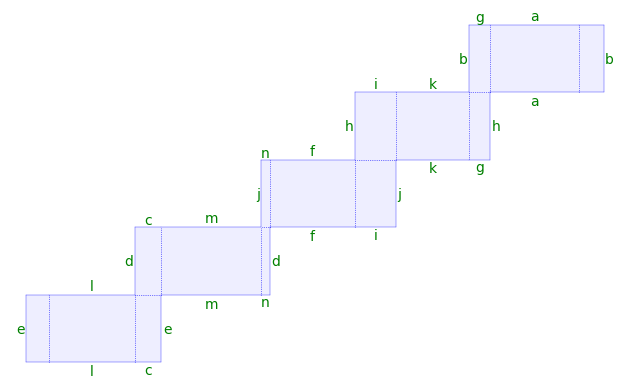

In [13]:
show_levels(s, -2, 2)
plt = s.plot()
plt

In [14]:
plt.save_image("surface.svg")
plt.save_image("surface.pdf")

In [15]:
F.<φ> = NumberField(golden_ratio.minpoly(), embedding=AA(golden_ratio))
φ

φ

In [16]:
AA(φ)

1.618033988749895?

In [17]:
TB = s.tangent_bundle(F)
v = TB(("A", 0), (0, 0), (1, φ))

In [18]:
traj = v.straight_line_trajectory()

In [19]:
traj.flow(1000)

In [0]:
traj?

In [20]:
seg = traj.segments()[0]

In [21]:
visited_levels = set(seg.polygon_label()[1] for seg in traj.segments())

In [22]:
level_min, level_max = min(visited_levels), max(visited_levels)
level_min, level_max

(-5, 11)

In [23]:
show_levels(s, level_min-1, level_max+1)

In [24]:
gs.will_plot_edge_labels = False
gs.will_plot_adjacent_edges = False

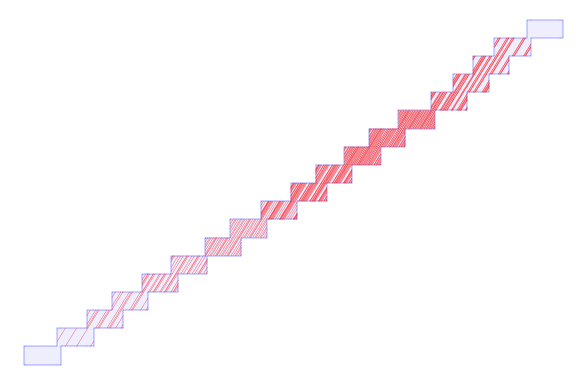

In [25]:
plt = s.plot() + traj.graphical_trajectory().plot(color="red", thickness=0.2)
plt

In [26]:
plt.save_image("trajectory.svg")
plt.save_image("trajectory.pdf")

In [27]:
plt.get_axes_range()

{'xmin': 0.0, 'xmax': 29.677380778802334, 'ymin': 0.0, 'ymax': 19.0}

## Random heights

In [28]:
class RandomHeights:
    r"""
    Return a random element in [0,H]^ℤ.
    """
    def __init__(self, H=5):
        self._d = {}
        self._H = H

    def __call__(self, n):
        try:
            return self._d[n]
        except KeyError:
            n = ZZ(n)
            if n not in self._d:
                val = QQ(self._H*random())
                self._d[n] = val
                return val
            else:
                return self._d[n]


In [29]:
h = RandomHeights(16)

In [30]:
h(2)

144348771/10571611

In [31]:
h(2**100)

485269457/44088398

In [32]:
h(2**100)

485269457/44088398

In [33]:
parent(h(2**100))

Rational Field

In [34]:
class RandomSurfaceH(Surface):
    r"""
    Constructs a random staircase surface.

    These are made of stair steps of width 2 and variable heights.

    Each stair step is cut up into 2 rectangles:

    - "A" - rectangle glued to previous stair step
    - "B" - rectangle glued to next stair step

    Rectangle sides are numbered 0, 1, 2, 3:

    - 0 -- top
    - 1 -- right
    - 2 -- bottom
    - 3 -- left
    """
    def __init__(self, h=None, H = 5):
        if h is None:
            self._h = RandomHeights(H)
        else:
            assert type(h) == RandomHeights
            self._h = h

        Surface.__init__(self, QQ, ("A", ZZ(0)), finite=False)

    def polygon(self, label):
        r"""
        Rectangle edges are numbered 0, 1, 2, 3:

        - 0 -- bottom
        - 1 -- right
        - 2 -- top
        - 3 -- left
        """
        letter, n = label
        if letter == "A" or letter == "B":
            h = self._h(n)
        else:
            raise ValueError("A label should be a pair consisting "
                             "of a letter and an integer. The letters "
                             "should be one of 'A'or 'B'")
        return polygons.rectangle(QQ.one(), h)

    def opposite_edge(self, label, e):
        r"""
        Rectangle edges are numbered 0, 1, 2, 3:

        - 0 -- bottom
        - 1 -- right
        - 2 -- top
        - 3 -- left
        """
        letter, n = label
        if e == 0:
            if letter == "A":
                return (("B", n - 1), 2)
            elif letter == "B":
                return (("A", n + 1), 2)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A' or 'B'")
        elif e == 1:
            if letter == "A":
                return (("B", n), 3)
            elif letter == "B":
                return (("A", n), 3)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A' or 'B'")
        elif e == 2:
            if letter == "A":
                return (("B", n - 1), 0)
            elif letter == "B":
                return (("A", n + 1), 0)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A' or 'B'")
        elif e == 3:
            if letter == "A":
                return (("B", n), 1)
            elif letter == "B":
                return (("A", n), 1)
            else:
                raise ValueError("A label should be a pair consisting "
                                 "of a letter and an integer. The letters "
                                 "should be one of 'A' or 'C'")
        else:
            raise ValueError("This surface is made of rectangles so the edge e "
                             "should be 0, 1, 2, or 3.")


In [68]:
t = RandomSurfaceH()
TestSuite(s).run(skip="_test_pickling")

In [69]:
t = TranslationSurface(t)
TestSuite(s).run(skip="_test_pickling")

In [70]:
gt = t.graphical_surface(edge_labels="letter")
gt.will_plot_edge_labels = True
gt.will_plot_polygon_labels = False
if "color" in gt.polygon_options:
    del gt.polygon_options["color"]
gt.polygon_options["rgbcolor"] = "#eef"
gt.edge_label_options["position"] = "outside"
gt.edge_label_options["t"] = 0.5
gt.edge_label_options["push_off"] = 0.02
gt.edge_label_options["color"] = "green"
gt.will_plot_adjacent_edges = True
gt.adjacent_edge_options["thickness"] = 0.5
gt.non_adjacent_edge_options["thickness"] = 0.25

In [71]:
def show_levelsH(t, a, b, gt=None):
    r"""
    Show only the levels ``a`` through ``b`` of the random surface ``s``.

    Here a and b should be integers, with a <= 0 <= b. The parameter
    gs should be a graphical surface, or ``None`` to use the default
    graphical surface.
    """
    if gt is None:
        gt = t.graphical_surface()
    # Hide all labels
    for label in gt.visible():
        gt.hide(label)
    gt.make_visible(("A", a))
    gt.make_adjacent(("A", a), 1)
    for n in range(a + 1, b + 1):
        gt.make_adjacent(("B", n - 1), 2)
        gt.make_adjacent(("A", n), 1)

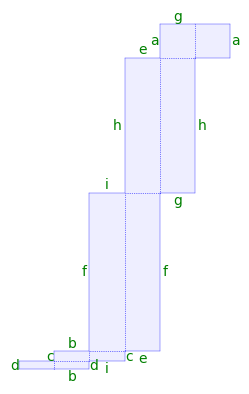

In [72]:
show_levelsH(t, -2, 2)
plt = t.plot()
plt

In [73]:
TBt = t.tangent_bundle(F)
w = TBt(("A", 0), (0, 0), (1, φ))

In [74]:
orb = w.straight_line_trajectory()

In [75]:
orb.flow(1000)

In [76]:
seg = orb.segments()[0]

In [77]:
visited_levels = set(seg.polygon_label()[1] for seg in orb.segments())

In [78]:
level_min, level_max = min(visited_levels), max(visited_levels)
level_min, level_max

(-2, 5)

In [79]:
show_levelsH(t, level_min-1, level_max+1)

In [80]:
gt.will_plot_edge_labels = False
gt.will_plot_adjacent_edges = False

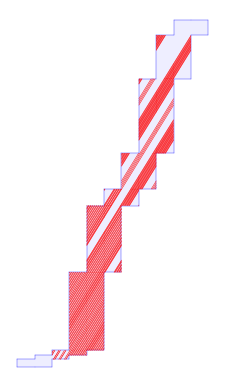

In [81]:
plt = t.plot() + orb.graphical_trajectory().plot(color="red", thickness=0.2)
plt